In [243]:
import numpy as np
from matplotlib import pyplot as plt
from cycler import cycler
plt.rc('axes', prop_cycle=cycler(color=['0.0', '0.4', '0.8']))
import matplotlib; matplotlib.rcParams.update({'font.size': 18})

In [244]:
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
from IPython.display import HTML
import course_helpers as chh
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="06-Cross-Validation.ipynb",
)

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 23 cell(s):
 cell_index  slide_id                                  tags
          3           slide_hide_prompt, slide_remove_input
          7 slide-1-0 slide_hide_prompt, slide_remove_input
          9 slide-1-1 slide_hide_prompt, slide_remove_input
         13 slide-3-0 slide_hide_prompt, slide_remove_input
         14 slide-3-1 slide_hide_prompt, slide_remove_input
         15 slide-3-1 slide_hide_prompt, slide_remove_input
         17 slide-3-3 slide_hide_prompt, slide_remove_input
         19 slide-4-0 slide_hide_prompt, slide_remove_input
         21 slide-4-1 slide_hide_prompt, slide_remove_input
         23 slide-4-2 slide_hide_prompt, slide_remove_input
         25 slide-5-0 slide_hide_prompt, slide_remove_input
         27 slide-5-1 slide_hide_prompt, slide_remove_input
         29 slide-5-2 slide_hide_prompt, slide_remove_input
         31 slide-5-3 slide_hide_prompt, slide_remove_input
         34 slide-6-0 slide_hide_prompt, slide_remove_input


In [245]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

In [246]:
# The 24 patients, the three specifications being compared, the palette, and
# the primitives the diagrams are drawn from. The analysis lives in the slide
# cells, not here.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression

TRAIN = "#2E9BE6"          # rows used for training
TEST  = "#F5A623"          # rows held out for testing
INK   = "#1A1A1A"
CAP   = "#3C3C3C"          # caption grey
GREY  = "#BFBFBF"
RED   = "#B3121F"
DOT   = (0, (1.2, 1.8))    # the dotted rule on a divided column

# Rows arrive already scrambled, the way a real file would, so four contiguous
# blocks are four unrelated groups of patients.
PATIENTS = pd.DataFrame({
    "Weight":   [128, 150, 171, 125, 123, 161, 196, 125, 118, 145, 130, 131,
                 177, 127, 157, 147, 213, 163, 168, 185, 144, 162, 196, 179],
    "Age":      [34, 60, 56, 35, 58, 53, 49, 31, 37, 56, 47, 32,
                 53, 32, 65, 59, 43, 45, 40, 38, 56, 53, 38, 56],
    "Exercise": [2, 1, 0, 3, 6, 7, 4, 2, 2, 7, 3, 0,
                 3, 3, 0, 2, 4, 1, 2, 0, 4, 2, 6, 1],
    "Smoker":   [1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1,
                 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1],
    "BP":       [103, 118, 120, 99, 99, 118, 119, 105, 106, 102, 100, 106,
                 113, 98, 119, 118, 120, 117, 106, 124, 112, 113, 111, 125],
})

BP = PATIENTS["BP"].to_numpy(float)
WEIGHT = PATIENTS["Weight"].to_numpy(float)
X_WEIGHT = WEIGHT.reshape(-1, 1)
X_ALL = PATIENTS[["Weight", "Age", "Exercise", "Smoker"]].to_numpy(float)
FOLDS = KFold(4)           # no shuffle needed: the rows are already scrambled

# the three candidates, in the order they get argued about
SPECS = [
    ("weight", X_WEIGHT, lambda: LinearRegression()),
    ("weight, age, exercise, smoking", X_ALL, lambda: LinearRegression()),
    ("all four, squares and interactions", X_ALL,
     lambda: make_pipeline(StandardScaler(),
                           PolynomialFeatures(2, include_bias=False),
                           LinearRegression())),
]


# ---- the diagram primitives -------------------------------------------------

def panel(w=11.0, h=4.9):
    """A blank canvas in 0..1 coordinates, which is how the diagrams are laid out."""
    fig, ax = plt.subplots(figsize=(w, h))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    return fig, ax


def column(ax, n_blocks=1, test=(), x=0.05, width=0.055, top=0.95, bot=0.05,
           dotted=None):
    """The data column. Amber marks a block being tested this round.

    Dotted dividers and a dotted outline appear once the column is cut up.
    """
    if dotted is None:
        dotted = n_blocks > 1
    h = (top - bot) / n_blocks
    for b in range(n_blocks):
        y = top - (b + 1) * h
        ax.add_patch(plt.Rectangle((x, y), width, h, zorder=2,
                                   facecolor=TEST if b in test else TRAIN,
                                   edgecolor="none"))
        if dotted and b:
            ax.plot([x, x + width], [y + h, y + h], color=INK, lw=1.0,
                    ls=DOT, zorder=3)
    if dotted:
        ax.add_patch(plt.Rectangle((x, bot), width, top - bot, fill=False,
                                   edgecolor=INK, lw=1.0, ls=DOT, zorder=3))
    return x + width


def caption(ax, text, x=0.58, y=0.6, size=18, ha="center"):
    """Centred grey caption text, set the way his slides set it."""
    ax.text(x, y, text, ha=ha, va="center", fontsize=size, color=CAP,
            linespacing=1.6)


def arrow(ax, x0, x1, y, color=None, lw=1.6):
    ax.annotate("", xy=(x1, y), xytext=(x0, y), annotation_clip=False,
                arrowprops=dict(arrowstyle="-|>", color=color or INK,
                                lw=lw, shrinkA=0, shrinkB=0))


def crossed_arrow(ax, x0, x1, y):
    """An arrow with a red X struck through it."""
    arrow(ax, x0, x1, y)
    mx, s = (x0 + x1) / 2.0, (x1 - x0) * 0.20
    for dy in (1, -1):
        ax.plot([mx - s, mx + s], [y - 0.08 * dy, y + 0.08 * dy],
                color=RED, lw=3.6, solid_capstyle="round", zorder=4)


def gather(ax, x0, x1, y_lo, y_hi, y_mid):
    """Two curves collecting the training blocks into a single arrow."""
    t = np.linspace(0, 1, 80)
    for y_end in (y_hi, y_lo):
        ax.plot(x0 + (x1 - x0) * t,
                y_mid + (y_end - y_mid) * (1 - t) ** 2.4,
                color=INK, lw=1.5)
    arrow(ax, x1, x1 + 0.13, y_mid)


def draw_scatter(ax, line=False, test=(), title=None):
    """Weight against blood pressure, amber for held-out patients.

    line fits blood pressure on weight using whatever is not held out.
    """
    test = set(test)
    keep = [i for i in range(len(BP)) if i not in test]
    for i in range(len(BP)):
        ax.scatter([WEIGHT[i]], [BP[i]], s=140, zorder=3,
                   color=TEST if i in test else TRAIN,
                   edgecolor="white", linewidth=1.2)
    if line:
        fitted = LinearRegression().fit(X_WEIGHT[keep], BP[keep])
        grid = np.linspace(112, 220, 100).reshape(-1, 1)
        ax.plot(grid.ravel(), fitted.predict(grid), color=INK,
                linestyle=":", linewidth=2.6, zorder=2)
    ax.set_xlabel("Weight")
    ax.set_xlim(110, 222)
    ax.set_ylim(92, 132)
    ax.text(0, 1.03, "Blood\nPressure", transform=ax.transAxes,
            ha="left", va="bottom", fontsize=15, color=INK)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    if title:
        ax.set_title(title, fontsize=16, color=INK, pad=34)

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Cross Validation

### Choosing a model, and getting a sense of how well it will work

Causal Machine Learning

<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

## Start With Some Data

We want to use weight, age, exercise and smoking to predict a patient's
<b style="color:#73000A;">blood pressure</b>.

In [247]:
display(PATIENTS.head(6))

,Weight,Age,Exercise,Smoker,BP
0,128,34,2,1,103
1,150,60,1,1,118
2,171,56,0,0,120
3,125,35,3,1,99
4,123,58,6,1,99
5,161,53,7,1,118


### Then, When a New Patient Shows Up...

- Measure the same four variables on someone new, and predict their blood
pressure.

In [248]:
new_patient = pd.DataFrame({
    "Weight": [168], "Age": [52], "Exercise": [2],
    "Smoker": [0], "BP": ["???"],
})
display(new_patient)

,Weight,Age,Exercise,Smoker,BP
0,168,52,2,0,???


## First, Which Method?

1. We have focused on OLS so far...
2. Logistic Regression?
3. KNN?

How do we decide?

### What Cross Validation Is For

<b style="color:#73000A;">Cross validation</b> lets us compare different models and methods and get a sense of how well they will work in practice.

## All the Data

This column is everything we collected about our patients.

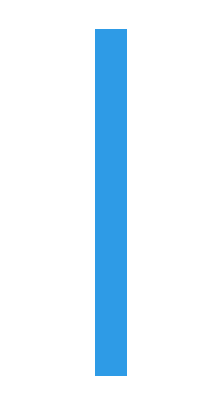

In [249]:
fig, ax = panel(2.6, 5.0)
column(ax, 1, x=0.42, width=0.16)
plt.show()

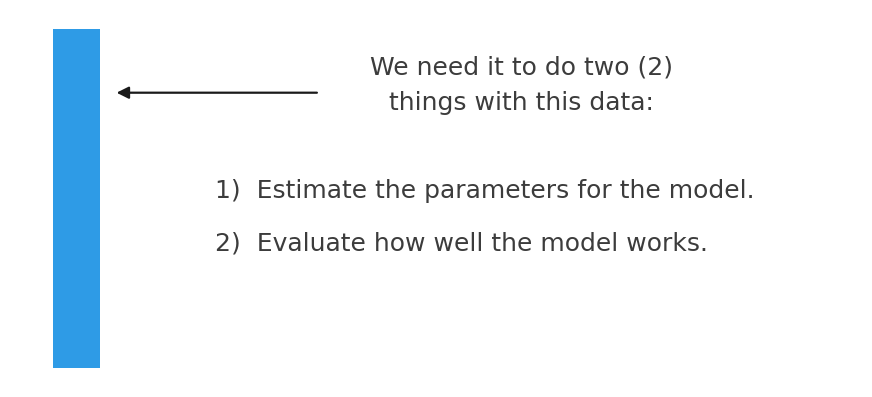

In [250]:
fig, ax = panel()
right = column(ax, 1)
arrow(ax, 0.36, right + 0.02, 0.78)
caption(ax, "We need it to do two (2)\nthings with this data:", x=0.60, y=0.80)
caption(ax, "1)  Estimate the parameters for the model.", x=0.24, y=0.52, ha="left")
caption(ax, "2)  Evaluate how well the model works.", x=0.24, y=0.38, ha="left")
plt.show()

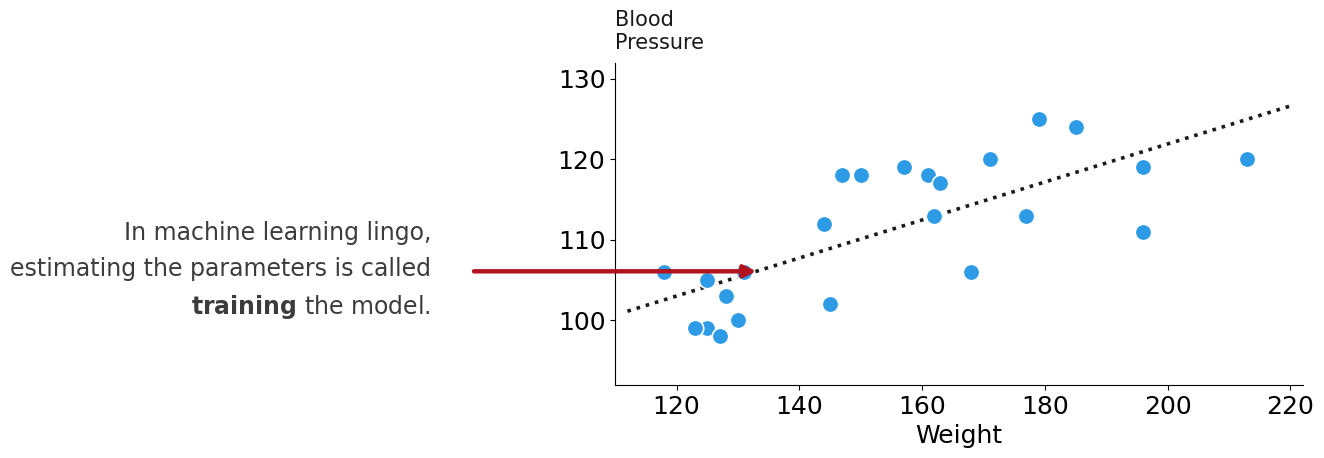

In [251]:
fig, ax = plt.subplots(figsize=(12.5, 4.6))
fig.subplots_adjust(left=0.42, right=0.97, top=0.88, bottom=0.18)
draw_scatter(ax, line=True)

# aim at a point on the line itself, so the tip cannot land short of it
fitted = LinearRegression().fit(X_WEIGHT, BP)
x_tip = 133.0
y_tip = float(fitted.predict(np.array([[x_tip]]))[0])

ax.annotate("", xy=(x_tip, y_tip), xytext=(x_tip - 46, y_tip),
            annotation_clip=False,
            arrowprops=dict(arrowstyle="-|>", color=RED, lw=3.2,
                            shrinkA=0, shrinkB=0))
ax.text(x_tip - 53, y_tip,
        "In machine learning lingo,\nestimating the parameters is called\n"
        "$\\bf{training}$ the model.",
        ha="right", va="center", fontsize=17, color=CAP, linespacing=1.6,
        clip_on=False)
plt.show()

### The second job...

We need to find out whether this model will do a good job predicting
<b style="color:#73000A;">new patients</b>.

Evaluating a model is called <b style="color:#73000A;">testing</b> it.

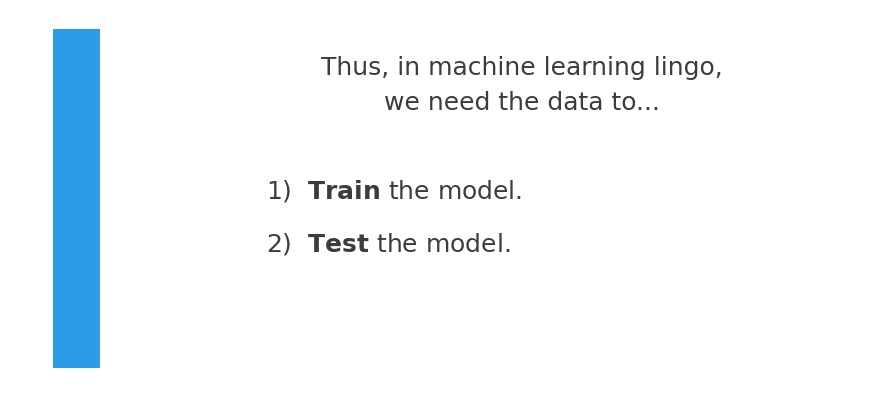

In [252]:
fig, ax = panel()
column(ax, 1)
caption(ax, "Thus, in machine learning lingo,\nwe need the data to...", x=0.60, y=0.80)
caption(ax, "1)  $\\bf{Train}$ the model.", x=0.30, y=0.52, ha="left")
caption(ax, "2)  $\\bf{Test}$ the model.", x=0.30, y=0.38, ha="left")
plt.show()

## A Terrible Approach

Use <b style="color:#73000A;">all</b> the data to estimate the coefficients, and there is nothing left
to test with.

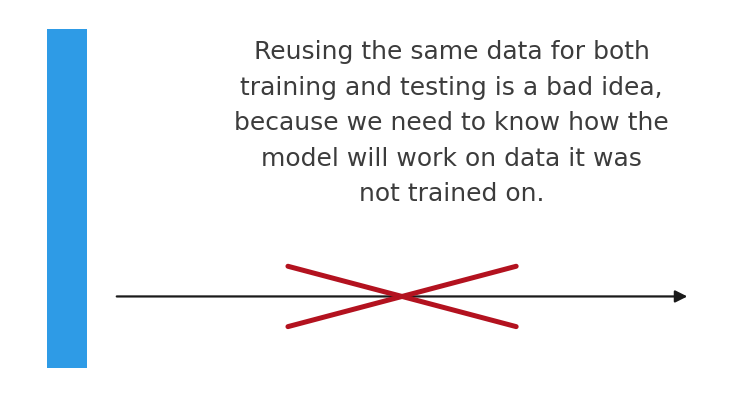

In [253]:
fig, ax = panel(9.5, 4.9)
right = column(ax, 1)
caption(ax, "Reusing the same data for both\ntraining and testing is a bad idea,\n"
            "because we need to know how the\nmodel will work on data it was\n"
            "not trained on.", x=0.60, y=0.70)
crossed_arrow(ax, right + 0.04, 0.92, 0.24)
plt.show()

### A Slightly Better Idea

Use the first <b style="color:#73000A;">75%</b> of the data for training and the last <b style="color:#73000A;">25%</b> for testing.

Then compare candidates by how well each one predicted the test patients.

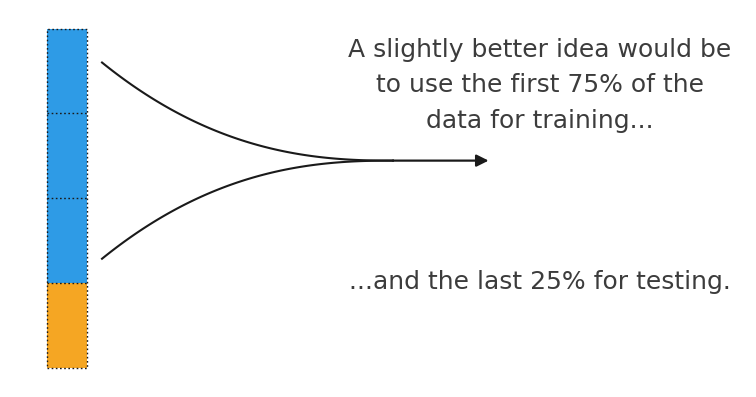

In [254]:
fig, ax = panel(9.5, 4.9)
right = column(ax, 4, test=(3,))
gather(ax, right + 0.02, 0.52, 0.34, 0.86, 0.60)
caption(ax, "A slightly better idea would be\nto use the first 75% of the\n"
            "data for training...", x=0.72, y=0.80)
caption(ax, "...and the last 25% for testing.", x=0.72, y=0.28)
plt.show()

### But Why That Block?

- What if we used the <b style="color:#73000A;">first 25%</b> for testing
- Or one of the <b style="color:#73000A;">middle blocks</b>

Nothing makes the last quarter special.

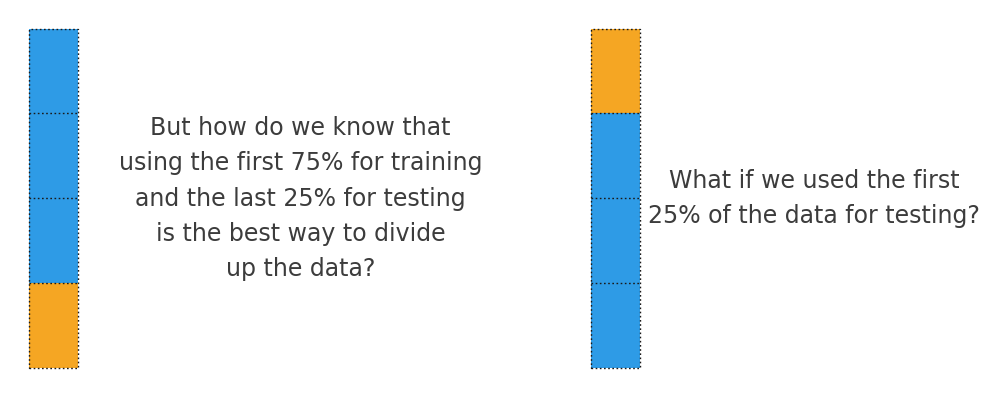

In [255]:
fig, ax = panel(12.5, 4.9)

column(ax, 4, test=(3,), x=0.02, width=0.05)
caption(ax, "But how do we know that\nusing the first 75% for training\n"
            "and the last 25% for testing\nis the best way to divide\nup the data?",
        x=0.30, y=0.5, size=17)

column(ax, 4, test=(0,), x=0.60, width=0.05)
caption(ax, "What if we used the first\n25% of the data for testing?",
        x=0.83, y=0.5, size=17)
plt.show()

## Use Them All, One at a Time

Rather than worry about which block is best for testing, use every block, one
at a time, and <b style="color:#73000A;">summarize the results</b> at the end.

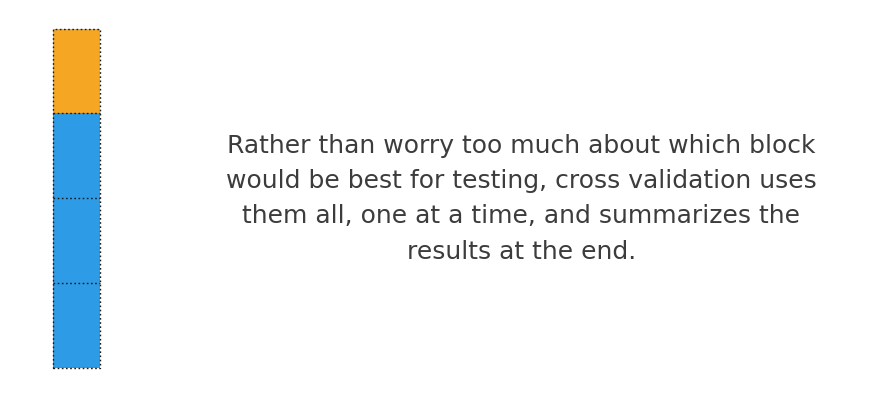

In [256]:
fig, ax = panel()
column(ax, 4, test=(0,))
caption(ax, "Rather than worry too much about which block\n"
            "would be best for testing, cross validation uses\n"
            "them all, one at a time, and summarizes the\n"
            "results at the end.", x=0.60, y=0.5)
plt.show()

### Round 1: Train on Three, Test on the Fourth

Estimate on the first three blocks, predict the six patients in the last block, and measure the error.

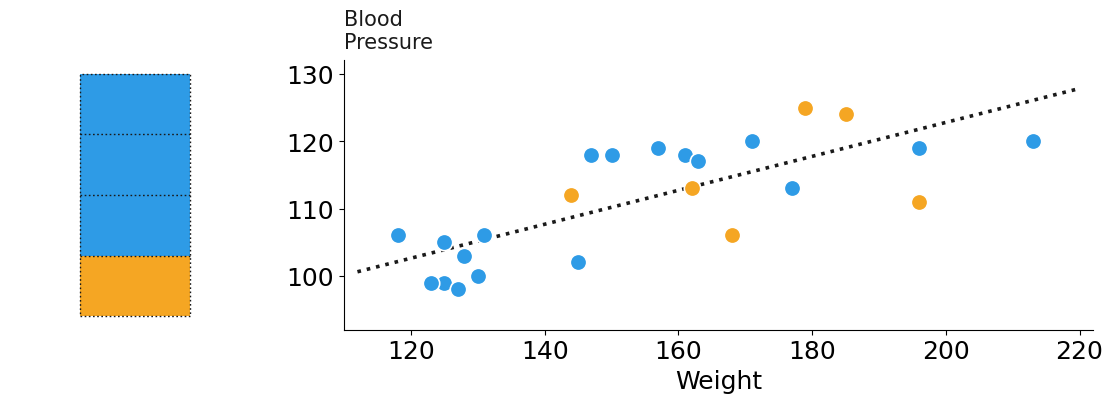

In [257]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4),
                             gridspec_kw={"width_ratios": [1, 3]})
a1.set_xlim(0, 1); a1.set_ylim(0, 1); a1.axis("off")
column(a1, 4, test=(3,), x=0.28, width=0.44)
draw_scatter(a2, line=True, test=range(18, 24))
plt.tight_layout(); plt.show()

### Round 2: Move the Test Block

Same model, same procedure, a different six patients held out.

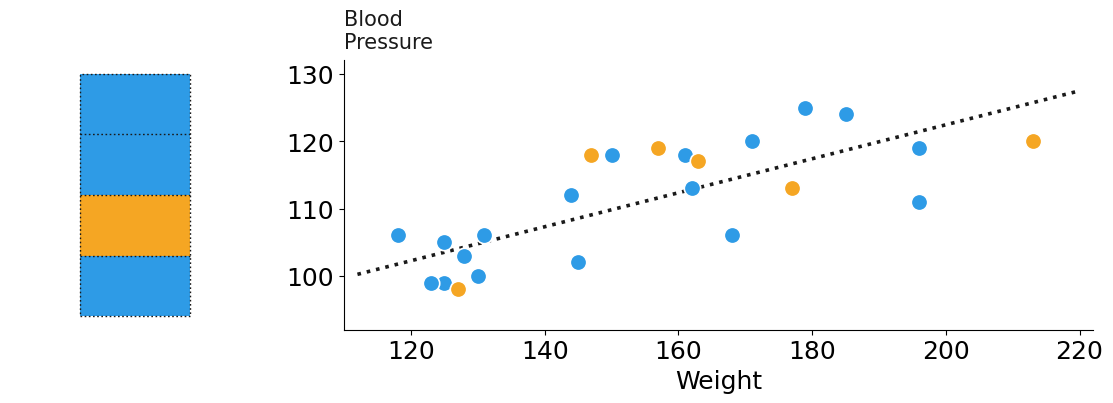

In [258]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4),
                             gridspec_kw={"width_ratios": [1, 3]})
a1.set_xlim(0, 1); a1.set_ylim(0, 1); a1.axis("off")
column(a1, 4, test=(2,), x=0.28, width=0.44)
draw_scatter(a2, line=True, test=range(12, 18))
plt.tight_layout(); plt.show()

### Rounds 3 and 4: Keep Going

Every block takes a turn being the test set.

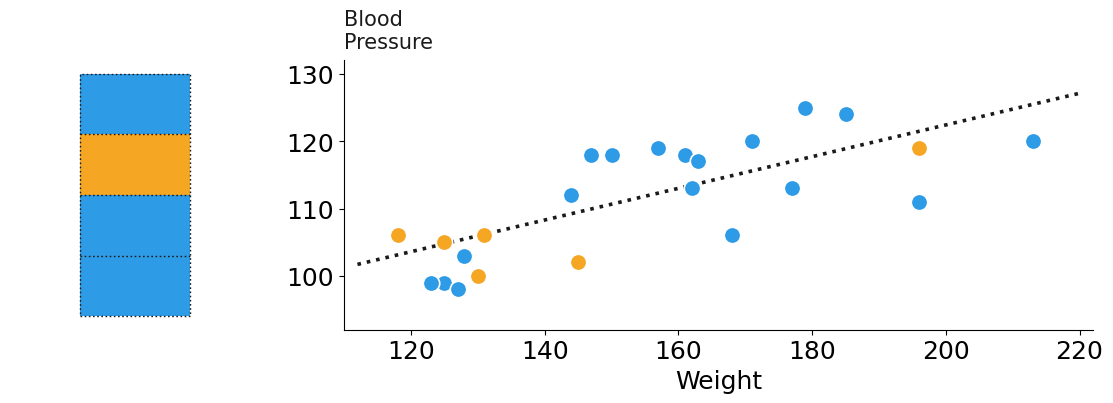

In [259]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4),
                             gridspec_kw={"width_ratios": [1, 3]})
a1.set_xlim(0, 1); a1.set_ylim(0, 1); a1.axis("off")
column(a1, 4, test=(1,), x=0.28, width=0.44)
draw_scatter(a2, line=True, test=range(6, 12))
plt.tight_layout(); plt.show()

### Two Numbers for Each Candidate

<b style="color:#73000A;">Own sample</b>: fit the candidate on all 24 patients, then score it on those
same 24. The error on the data it was fitted to.

<b style="color:#73000A;">Cross-Validation (CV) error</b>: run the four rounds we just did, and average the four fold
errors. The error on patients it never saw.

Both are in points of blood pressure, and smaller is better.

### Step 1: Residuals

Fit blood pressure on weight and you get

$$\widehat{BP} = 74.69 + 0.2361 \times \text{Weight}$$

Patient 1 weighs 128 and has a blood pressure of 103. The model says

$$74.69 + 0.2361 \times 128 = 104.91$$

so the <b style="color:#73000A;">residual</b> for that patient is $103 - 104.91 = -1.91$.

In [260]:
# blood pressure on weight, fitted here so this slide stands alone
fit_w = LinearRegression().fit(X_WEIGHT, BP)
pred_w = fit_w.predict(X_WEIGHT)
resid_w = BP - pred_w

print("BP-hat = %.2f + %.4f x Weight" % (fit_w.intercept_, fit_w.coef_[0]))
print()
print("%8s %8s %8s %11s %10s %18s"
      % ("patient", "weight", "actual", "predicted", "residual", "residual squared"))
for i in range(5):
    print("%8d %8.0f %8.0f %11.2f %10.2f %18.2f"
          % (i + 1, WEIGHT[i], BP[i], pred_w[i], resid_w[i], resid_w[i] ** 2))
print("%8s" % "...")

BP-hat = 74.69 + 0.2361 x Weight

 patient   weight   actual   predicted   residual   residual squared
       1      128      103      104.91      -1.91               3.64
       2      150      118      110.10       7.90              62.39
       3      171      120      115.06       4.94              24.41
       4      125       99      104.20      -5.20              27.04
       5      123       99      103.73      -4.73              22.35
     ...


### Step 2: Sample Error

$$\text{own sample error} \;=\; \sqrt{\frac{1}{n}\sum_{i=1}^{n} e_i^{2}}
\qquad\text{where}\qquad e_i = \text{actual}_i - \text{predicted}_i$$

- <b style="color:#73000A;">Square each residual</b>, so $-6$ and $+6$ do not cancel
- <b style="color:#73000A;">Average over all n patients</b>, which is 24 here
- <b style="color:#73000A;">Take the square root</b>, to get back into points of blood pressure

Squaring also charges more for one large residual than for several small ones.

In [261]:
# refitted rather than reusing anything, so the number cannot drift
fit_w = LinearRegression().fit(X_WEIGHT, BP)
resid_w = BP - fit_w.predict(X_WEIGHT)
ssr_w = float(np.sum(resid_w ** 2))
n = len(BP)

print("blood pressure on weight, all 24 patients")
print()
print("add up the 24 squared residuals:   %8.2f" % ssr_w)
print("divide by n = %d:                   %8.4f" % (n, ssr_w / n))
print("take the square root:              %8.4f" % np.sqrt(ssr_w / n))
print()
print("so the own sample error is %.2f points of blood pressure"
      % np.sqrt(ssr_w / n))

blood pressure on weight, all 24 patients

add up the 24 squared residuals:     760.47
divide by n = 24:                    31.6861
take the square root:                5.6290

so the own sample error is 5.63 points of blood pressure


### Step 3: The Cross Validation Error

Each round already produced one of these numbers, computed exactly the same
way, on the six patients that round held out.

$$\text{CV error} \;=\; \frac{5.76 + 4.19 + 6.22 + 6.89}{4} \;=\; \frac{23.06}{4} \;=\; 5.77$$

The only difference from step 2 is <b style="color:#73000A;">which patients the residuals come from</b>.

In [262]:
fold_errors = []
for k, (train_rows, test_rows) in enumerate(FOLDS.split(X_WEIGHT)):
    ff = LinearRegression().fit(X_WEIGHT[train_rows], BP[train_rows])
    held_out_miss = BP[test_rows] - ff.predict(X_WEIGHT[test_rows])
    fold_errors.append(np.sqrt(np.mean(held_out_miss ** 2)))
    print("round %d: 6 held-out patients, error = %.2f" % (k + 1, fold_errors[-1]))

print()
print("sum of the four:  %.2f" % sum(fold_errors))
print("divide by 4:      %.4f" % np.mean(fold_errors))

round 1: 6 held-out patients, error = 5.76
round 2: 6 held-out patients, error = 4.19
round 3: 6 held-out patients, error = 6.22
round 4: 6 held-out patients, error = 6.89

sum of the four:  23.06
divide by 4:      5.7660


### Do This Over Specifications or Even Models

In [263]:
print("%-36s %11s %9s" % ("specification", "own sample", "CV error"))
for name, Xd, make in SPECS:
    fit_s = make().fit(Xd, BP)
    train = np.sqrt(np.mean((BP - fit_s.predict(Xd)) ** 2))
    cv = -cross_val_score(make(), Xd, BP, cv=FOLDS,
                          scoring="neg_root_mean_squared_error")
    print("%-36s %11.2f %9.2f" % (name, train, cv.mean()))

specification                         own sample  CV error
weight                                      5.63      5.77
weight, age, exercise, smoking              3.66      4.24
all four, squares and interactions          2.88     13.15


### Own Sample VS Cross-Validation

| specification | own sample | CV error |
|---|---|---|
| weight | 5.63 | 5.77 |
| weight, age, exercise, smoking | 3.66 | <b style="color:#73000A;">4.24</b> |
| all four, squares and interactions | <b style="color:#73000A;">2.88</b> | 13.15 |

- Smallest on its <b style="color:#73000A;">own sample</b>: all four, squares and interactions, at 2.88
- Smallest on patients it <b style="color:#73000A;">never saw</b>: weight, age, exercise and smoking, at 4.24
- The kitchen sink scores 13.15 out of sample, worse than predicting the
  average blood pressure for everybody, which scores 8.36

<b style="color:#73000A;">When we care about predicting blood pressure for patients outside our sample, cross validation picks weight, age, exercise and smoking.</b>

It picks the best of the three we handed it. A specification we never tried could still beat it.

## Four Blocks Is Four-Fold

We divided the data into four blocks, so that was <b style="color:#73000A;">four-fold cross validation</b>.

The number of blocks is arbitrary.

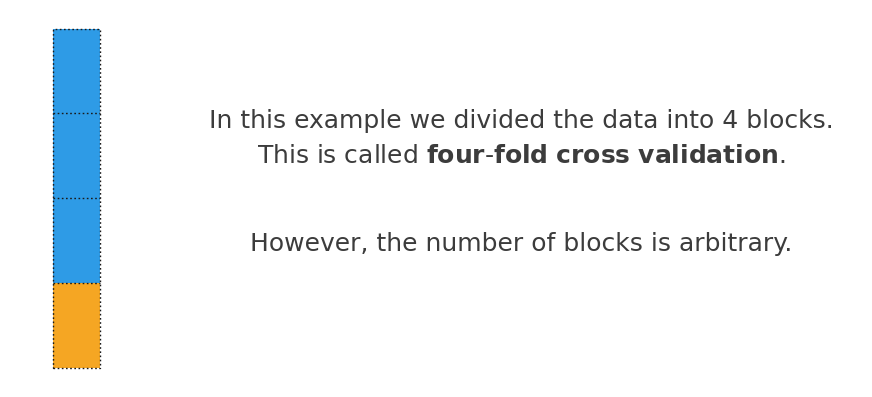

In [264]:
fig, ax = panel()
column(ax, 4, test=(3,))
caption(ax, "In this example we divided the data into 4 blocks.\n"
            "This is called $\\bf{four}$-$\\bf{fold}$ $\\bf{cross}$ $\\bf{validation}$.",
        x=0.60, y=0.66)
caption(ax, "However, the number of blocks is arbitrary.", x=0.60, y=0.38)
plt.show()

### In General: k-Fold Cross Validation

Split the data into <b style="color:#73000A;">k</b> blocks. Then run <b style="color:#73000A;">k</b> rounds:

- Hold out one block
- Fit on the other $k-1$
- Score the block that was held out

$$\text{CV}_k \;=\; \frac{1}{k}\sum_{j=1}^{k} \text{error}_j$$

We just did $k = 4$.

### One Block Per Patient

In the extreme, call each individual patient a block. Each one gets tested on
its own.

That is <b style="color:#73000A;">leave one out cross validation</b>.

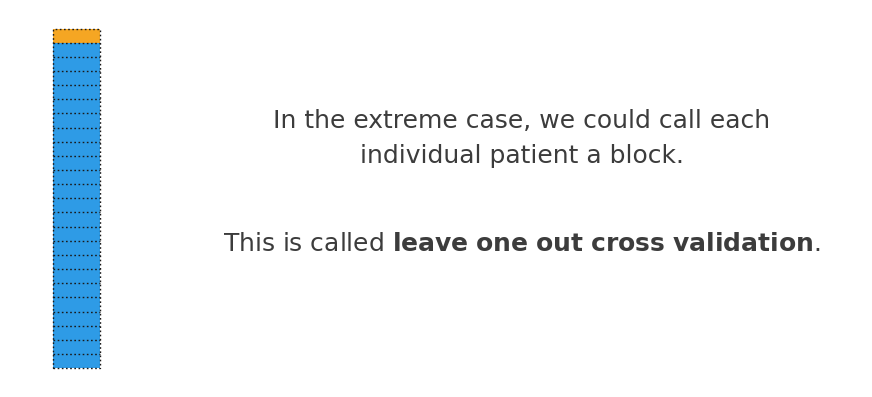

In [265]:
fig, ax = panel()
column(ax, 24, test=(0,))
caption(ax, "In the extreme case, we could call each\nindividual patient a block.",
        x=0.60, y=0.66)
caption(ax, "This is called $\\bf{leave}$ $\\bf{one}$ $\\bf{out}$ $\\bf{cross}$ $\\bf{validation}$.",
        x=0.60, y=0.38)
plt.show()

### Ten Is What People Actually Use

In practice it is very common to divide the data into ten blocks.

<b style="color:#73000A;">Ten-fold cross validation</b>.

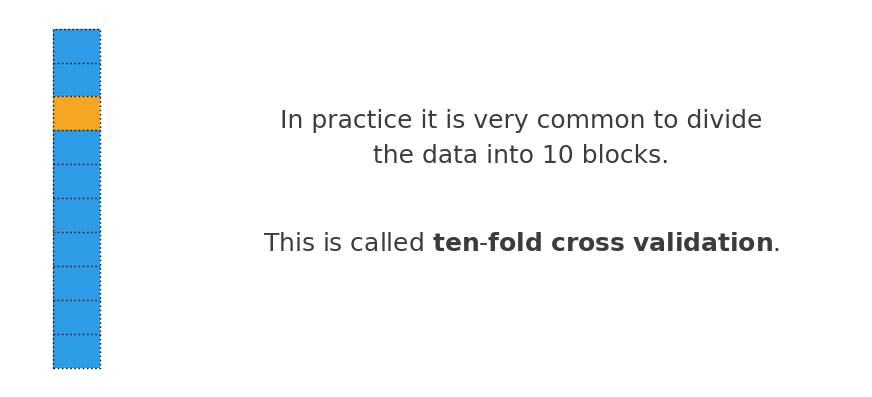

In [266]:
fig, ax = panel()
column(ax, 10, test=(2,))
caption(ax, "In practice it is very common to divide\nthe data into 10 blocks.",
        x=0.60, y=0.66)
caption(ax, "This is called $\\bf{ten}$-$\\bf{fold}$ $\\bf{cross}$ $\\bf{validation}$.",
        x=0.60, y=0.38)
plt.show()

## So How Big Should k Be?

- If k is too small (e.g., k=2): The model only trains on 50% of the data, which might lead to an underestimation of its true performance.

- If k is too large (e.g.,Leave-One-Out Cross-Validation with large n) It provides an accurate estimate but is computationally expensive because the model must retrain thousands or millions of times.

- Most common are k=5, k=10
  - Balance between computational efficiency and statistical bias

## One Last Use: Tuning Parameters

- A <b style="color:#73000A;">tuning parameter</b> is a parameter that is not estimated
- Just sort of guessed.

### Guess It, Then Score It

K-fold cross validation can find the best value for that tuning parameter.

- Pick a value
- Score it by cross validation
- Keep the value that scores best

## When Do You Actually Do This?

You have sat through years of econometrics and never once cross validated
anything. That is not an oversight. You were answering a different question.

| | econometrics | machine learning |
|---|---|---|
| the question | what is the <b style="color:#73000A;">coefficient</b> | what will the <b style="color:#73000A;">outcome</b> be |
| you report | an estimate and a standard error | error on data it has not seen |
| it is right if | the estimate is unbiased | the prediction is close |
| cross validate? | <b style="color:#73000A;">no</b> | <b style="color:#73000A;">yes</b> |

## Key Ideas

- Data has <b style="color:#73000A;">two jobs</b> to do: train the model, and test it
- Using the same rows for both always prefers the biggest specification
- A single train test split works, but the verdict rides on one arbitrary cut
- Cross validation uses <b style="color:#73000A;">every block</b>, one at a time, and averages at the end
- Every observation is tested once, so nothing is wasted
- The number of blocks is up to you. Ten is the common choice
- The same procedure picks a <b style="color:#73000A;">tuning parameter</b>
- It answers a <b style="color:#73000A;">prediction</b> question. It says nothing about whether a
  coefficient is unbiased